In [1]:
import pandas as pd
import seaborn as sns
from torch.utils.data import DataLoader, Dataset,  SequentialSampler, TensorDataset, Subset
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import copy
from tqdm import tqdm
import numpy as np
from sklearn.decomposition import PCA
import torch
from torch.nn import CrossEntropyLoss, MSELoss
from functools import partial
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report
import random
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
import gc

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(device)
else:
    print("MPS device not found.")

cuda


In [3]:
model = AutoModelForSequenceClassification.from_pretrained('./bert-4_128-yahoo')
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=128, out_features=128, bias=True)
              (key): Linear(in_features=128, out_features=128, bias=True)
              (value): Linear(in_features=128, out_features=128, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=128, out_features=128, bias=True)
              (LayerNorm): LayerNorm((128,), eps=1e-1

In [4]:
class TestDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.sentences = df.iloc[:, 1:].apply(lambda x: ' '.join(x.dropna().astype(str)), axis=1).values
        self.labels = df.iloc[:, 0].values - 1  # Label을 0부터 시작하도록 조정
        self.tokenizer = tokenizer
    def __len__(self):
        return len(self.sentences)
    def __getitem__(self, idx):
        sentence = self.sentences[idx]
        inputs = self.tokenizer(sentence, truncation=True, max_length=512, padding='max_length', return_tensors="pt")
        label = torch.tensor(self.labels[idx])
        return inputs, label

In [5]:
# validation 데이터 가져오기
validation_data = "./validation.csv"
validation_df = pd.read_csv(validation_data, header=None, names=["class","question_title","question_body","answer"])
validation_dataset = TestDataset(validation_df, tokenizer)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)
# test 데이터 가져오기
test_data = "./test2.csv"
test_df = pd.read_csv(test_data, header=None, names=["class","question_title","question_body","answer"])
test_dataset = TestDataset(test_df, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [6]:
def extract_embeddings(outputs):
    return outputs.hidden_states[0], outputs.hidden_states[-1]

In [7]:
def select_true_example(model, num_labels, data_frame, data_loader, tokenizer, device):
    correct_predictions = [[] for _ in range(num_labels)]
    sorted_input_embeddings = []
    sorted_output_embeddings = []
    sorted_attention_masks = []
    class_dfs = []
    batch_start_idx = 0
    for batch in tqdm(data_loader, desc="Evaluating model"):
        inputs, labels = batch
        # Attention mask를 입력에서 추출
        attention_mask = inputs['attention_mask']
        inputs = {k: v.squeeze(1).to(device) for k, v in inputs.items()}
        labels = labels.to(device)

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)
            input_embeddings, output_embeddings = extract_embeddings(outputs)
        predictions = outputs.logits.argmax(dim=-1)
        
        for i in range(len(labels)):
            if predictions[i] == labels[i]:
                original_index = batch_start_idx + i
                correct_predictions[labels[i].item()].append((
                    outputs.logits[i, predictions[i]].item(), 
                    data_frame.iloc[original_index].tolist(), 
                    input_embeddings[i].cpu().numpy(), 
                    output_embeddings[i].cpu().numpy(), 
                    attention_mask[i].cpu().numpy().squeeze()  # Attention mask 저장
                ))
        batch_start_idx += len(labels)
    
    for i in range(num_labels):
        # logit 값에 따라 정렬
        correct_predictions[i].sort(key=lambda x: x[0], reverse=True)
        # 정렬된 데이터를 분리하여 저장
        sorted_class_data = [pred[1] for pred in correct_predictions[i]]
        sorted_input_embeds = [pred[2] for pred in correct_predictions[i]]
        sorted_output_embeds = [pred[3] for pred in correct_predictions[i]]
        sorted_attn_masks = [pred[4] for pred in correct_predictions[i]]  # Attention mask 정렬
        
        # 정렬된 데이터를 DataFrame으로 변환
        class_df = pd.DataFrame(sorted_class_data)
        class_dfs.append(class_df)
        
        sorted_input_embeddings.append(sorted_input_embeds)
        sorted_output_embeddings.append(sorted_output_embeds)
        sorted_attention_masks.append(sorted_attn_masks)  # Attention mask 저장
    
    return sorted_input_embeddings, sorted_attention_masks  # Attention mask도 반환

In [8]:
input_embeds, att_masks = select_true_example(model, 10, validation_df, validation_loader, tokenizer, device)

Evaluating model: 100%|██████████| 938/938 [00:18<00:00, 51.80it/s]


In [9]:
extract_embed_list=[]
extract_embed_list.extend(extract_top_n_embeddings(4, 10, input_embeds))
extract_embed_list.extend(extract_bottom_n_embeddings(0, 10, input_embeds))

NameError: name 'extract_top_n_embeddings' is not defined

In [9]:
def extract_top_n_embeddings(extract_num, class_num, embeds_list, attn_masks_list):
    return_embeds_list = []
    return_masks_list = []
    
    for i in range(extract_num):
        extracted_embeds = []
        extracted_masks = []
        
        for j in range(class_num):
            # 임베딩 추출
            class_embeds = np.array(embeds_list[j][i:i+1])
            class_embeds_tensor = torch.tensor(class_embeds)
            extracted_embeds.append(class_embeds_tensor)
            
            # 어텐션 마스크 추출
            class_attn_mask = np.array(attn_masks_list[j][i:i+1])
            class_attn_mask_tensor = torch.tensor(class_attn_mask)
            extracted_masks.append(class_attn_mask_tensor)
        
        # 임베딩과 어텐션 마스크를 각각의 리스트에 추가
        return_embeds_list.append(extracted_embeds)
        return_masks_list.append(extracted_masks)
    
    return return_embeds_list, return_masks_list

In [10]:
def extract_bottom_n_embeddings(extract_num, class_num, embeds_list, attn_masks_list):
    return_embeds_list = []
    return_masks_list = []

    for i in range(extract_num):
        extracted_embeds = []
        extracted_masks = []

        for j in range(class_num):
            # 임베딩 추출
            class_embeds = np.array(embeds_list[j][-(i+1):-(i)] or embeds_list[j][-(i+1):])
            class_embeds_tensor = torch.tensor(class_embeds)
            extracted_embeds.append(class_embeds_tensor)
            
            # 어텐션 마스크 추출
            class_attn_mask = np.array(attn_masks_list[j][-(i+1):-(i)] or attn_masks_list[j][-(i+1):])
            class_attn_mask_tensor = torch.tensor(class_attn_mask)
            extracted_masks.append(class_attn_mask_tensor)

        # 임베딩과 어텐션 마스크를 각각의 리스트에 추가
        return_embeds_list.append(extracted_embeds)
        return_masks_list.append(extracted_masks)

    return return_embeds_list, return_masks_list

In [11]:
def get_decimal_precision(value):
    str_value = str(value)
    if '.' in str_value:
        return len(str_value.split('.')[1])
    else:
        return 0

In [12]:
def perturb(embeds, eps, grad):
    perturbed_embeds = embeds - eps*grad.sign()
    return perturbed_embeds

In [13]:
def calculate_gradient(model, input_embeds, target_class, device):
    # print(input_embeds.shape)
    input_embeds = input_embeds.clone().detach().requires_grad_(True).to(device)
    target = torch.tensor([target_class]).to(device)
    outputs = model(inputs_embeds=input_embeds, labels=target)
    init_pred = outputs.logits.argmax(dim=-1)
    loss = outputs.loss
    model.zero_grad()
    loss.backward()
    data_grad = input_embeds.grad
    return loss, data_grad

In [14]:
def fgsm_attack(model, source, target, input_embeds, start_eps, eps_step, max_eps, device):
    input_embeds = input_embeds.to(device)
    digits = get_decimal_precision(eps_step)
    targeted_eps = start_eps
    loss, data_grad = calculate_gradient(model, input_embeds, target, device)
    first_diff_eps = math.inf
    
    while targeted_eps <= max_eps:
        # print(f"epsilon : {eps}")
        perturbed_embeds = perturb(input_embeds, targeted_eps, data_grad)
        adv_outputs = model(inputs_embeds = perturbed_embeds)
        adv_pred = adv_outputs.logits.argmax(dim=-1)
        # print(adv_pred)

        if first_diff_eps == math.inf and adv_pred.item() != source:
            first_diff_eps = targeted_eps
        
        if adv_pred.item() == target:
            # print(f"{eps} adv attack success!")
            break
        else:
            targeted_eps += eps_step
            targeted_eps = round(targeted_eps, digits)
    return targeted_eps, first_diff_eps

In [15]:
def calculate_all_epsilon(model, class_num, logit_example, step_eps=0.01, max_eps=10.0):
    first_changed_list = []
    targeted_list = []
    for i in range(0, class_num):
        # print(f"class {i}")
        targeted_temp = []
        first_changed_temp = []
        for j in range(0, class_num):
            if i == j:
                targeted_temp.append((i, j, math.inf))
                first_changed_temp.append((i, j, math.inf))
                continue
            eps, first_diff_eps = fgsm_attack(model, i, j, logit_example[i], 0.00, step_eps, max_eps, device)
            if eps >= max_eps:
                targeted_temp.append((i, j, math.inf))
            else:
                targeted_temp.append((i, j, eps))
            first_changed_temp.append((i, j, first_diff_eps))
        targeted_list.append(targeted_temp)
        first_changed_list.append(first_changed_temp)
        
    flat_targeted_list = [(source, target, eps) for sublist in targeted_list for source, target, eps in sublist if eps != math.inf]
    flat_first_changed_list = [(source, target, eps) for sublist in first_changed_list for source, target, eps in sublist if eps != math.inf and eps - (2*step_eps) >=0.00]
        
    return flat_targeted_list, flat_first_changed_list

In [188]:
negative_eps = []
positive_eps = []

for i in range(0, len(extract_embed_list)):
    targeted_eps, first_changed_eps = calculate_all_epsilon(model, 10, extract_embed_list[i], 0.01, 5.00)
    positive_eps.append(first_changed_eps)
    negative_eps.append(targeted_eps)

class 0
class 1
class 2
class 3
class 4
class 5
class 6
class 7
class 8
class 9
class 0
class 1
class 2
class 3
class 4
class 5
class 6
class 7
class 8
class 9
class 0
class 1
class 2
class 3
class 4
class 5
class 6
class 7
class 8
class 9
class 0
class 1
class 2
class 3
class 4
class 5
class 6
class 7
class 8
class 9


In [16]:
def generate_example(model, device, source, target, input_embeds, example_num, boundary_eps, step_eps):
    example_list = []
    example_label = []
    source_embedding = input_embeds[source].to(device)
    # Gradient 계산
    loss, data_grad = calculate_gradient(model, source_embedding, target, device)
    iter_num = 0
    while iter_num < example_num:
        # Perturbation 적용
        eps = random.uniform(boundary_eps, boundary_eps + step_eps) 
        generated_embeds = perturb(source_embedding, eps, data_grad)
        example_list.append(generated_embeds.cpu())  # CPU로 이동
        example_label.append(source)
        iter_num += 1
        del generated_embeds
        torch.cuda.empty_cache()  # GPU 메모리 캐시 비우기
    del source_embedding, loss, data_grad
    torch.cuda.empty_cache()  # 캐시 비우기
    return example_label, example_list

In [17]:
def adjust_examples(example_list, example_label, eps_list, embed_list, attn_mask_list, target_num, step_eps, generate_fn, model, device):
    if len(example_list) < target_num:
        diff = target_num - len(example_list)
        for _ in range(diff):
            random_index = random.randint(0, len(embed_list)-1)
            input_embed = embed_list[random_index]
            eps_values = eps_list[random_index]
            attn_mask = attn_mask_list[random_index]
            print(attn_mask.shape)
            if eps_values:
                source, target, eps = random.choice(eps_values)
                label, example = generate_fn(model, device, source, target, input_embed, 1, eps-2*step_eps, step_eps)
                example_label.extend(label)
                example_list.extend(example)
                attn_mask_list.extend(attn_mask.unsqueeze(0))
    elif len(example_list) > target_num:
        diff = len(example_list) - target_num
        for _ in range(diff):
            random_index = random.randint(0, len(example_list) - 1)
            example_list.pop(random_index)
            example_label.pop(random_index)
            attn_mask_list.pop(random_index)

In [18]:
def make_example(model, data_frame, data_loader, tokenizer, example_num, top_emb, bottom_emb, class_num, true_ratio, device, step_eps=0.01, max_eps=10.0):
    extract_embed_list = []
    extract_attn_list = []
    negative_eps = []
    positive_eps = []
    positive_attn_mask_list = []
    positive_example_list = []
    positive_example_label = []
    negative_example_list = []
    negative_example_label = []
    negative_attn_mask_list = []

    positive_num = int(round(example_num * true_ratio*0.01))
    negative_num = example_num - positive_num
    extract_num = top_emb + bottom_emb

    print("Generate positive num : ", positive_num)
    print("Generate negative num : ", negative_num)
    
    per_emb_positive_example_num = int(round(positive_num / extract_num))
    per_emb_negative_example_num = int(round(negative_num / extract_num))

    print("Extract Num : ", extract_num)
    print("Generate per embedding positive example num : ", per_emb_positive_example_num)
    print("Generate per embedding negative example num : ", per_emb_negative_example_num)

    input_embeds, attn_masks = select_true_example(model, class_num, data_frame, data_loader, tokenizer, device)
    
    # extract_embed_list.extend(extract_top_n_embeddings(top_emb, class_num, input_embeds))
    # extract_embed_list.extend(extract_bottom_n_embeddings(bottom_emb, class_num, input_embeds))

    extract_embed, extract_attn = extract_top_n_embeddings(top_emb, class_num, input_embeds, attn_masks)
    extract_embed_list.extend(extract_embed)
    extract_attn_list.extend(extract_attn)

    extract_embed, extract_attn = extract_bottom_n_embeddings(bottom_emb, class_num, input_embeds, attn_masks)
    extract_embed_list.extend(extract_embed)
    extract_attn_list.extend(extract_attn)

    for i in range(0, len(extract_embed_list)):
        targeted_eps, first_changed_eps = calculate_all_epsilon(model, class_num, extract_embed_list[i], step_eps, max_eps)
        positive_eps.append(first_changed_eps)
        negative_eps.append(targeted_eps)
        
    for i, (input_embed, attn_mask) in enumerate(zip(extract_embed_list, extract_attn_list)):
        for j, first_changed in enumerate(positive_eps[i]):
            per_positive_example_num = int(round(per_emb_positive_example_num / len(positive_eps[i])))
            source, target, eps = first_changed
            # print("per positive example num", per_positive_example_num)
            pos_label, pos_example = generate_example(model, device, source, target, extract_embed_list[i], per_positive_example_num, eps-2*step_eps, step_eps)
            positive_example_label.extend(pos_label)
            positive_example_list.extend(pos_example)
            for k in range(0, per_positive_example_num):
                positive_attn_mask_list.extend(attn_mask[source].unsqueeze(0))

        for j, targeted in enumerate(negative_eps[i]):
            per_negative_example_num = int(round(per_emb_negative_example_num / len(negative_eps[i])))
            source, target, eps = targeted
            # print("per negative example num", per_negative_example_num)
            neg_label, neg_example = generate_example(model, device, source, target, extract_embed_list[i], per_negative_example_num, eps, step_eps)
            negative_example_label.extend(neg_label)
            negative_example_list.extend(neg_example)
            for k in range(0, per_negative_example_num):
                negative_attn_mask_list.extend(attn_mask[source].unsqueeze(0))

    adjust_examples(positive_example_list, positive_example_label, positive_eps, extract_embed_list, positive_attn_mask_list, positive_num, step_eps, generate_example, model, device)
    adjust_examples(negative_example_list, negative_example_label, negative_eps, extract_embed_list, negative_attn_mask_list, negative_num, step_eps, generate_example, model, device)
    return positive_example_label, positive_example_list, positive_attn_mask_list, negative_example_label, negative_example_list, negative_attn_mask_list

In [19]:
def ret_classification_report(emb_list, label_list):
    predictions = []
    with torch.no_grad():
        for i, input_embeds in tqdm(enumerate(emb_list), total=len(emb_list), desc="Evaluating"):
            outputs = model(inputs_embeds=input_embeds.to(device))
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)
            predictions.extend(preds.cpu().numpy())
        report = classification_report(np.array(label_list), predictions)
    return report

In [20]:
def extract_cls_token(model, embedding_list, attn_masks_list, device):
    cls_token_list = []
    preds_list = []
    
    for input_embeds, attn_mask in zip(embedding_list, attn_masks_list):
        # input_embeds와 attention mask를 텐서로 변환하여 GPU로 이동
        input_embeds = input_embeds.to(device)
        attn_mask = attn_mask.to(device)
        
        with torch.no_grad():
            # 모델에 inputs_embeds와 attention_mask를 모두 입력
            outputs = model(inputs_embeds=input_embeds, attention_mask=attn_mask, output_hidden_states=True)
        preds = outputs.logits.argmax(dim=-1)

        # CLS 토큰의 임베딩 추출
        cls_token_embed = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
        cls_token_list.extend(cls_token_embed)
        preds_list.append(preds.item())
    
    return np.array(cls_token_list), preds_list

In [21]:
def select_random_samples(token_list, num_samples=10):
    return random.sample(token_list, num_samples)

In [22]:
def visualize_embeddings_TSNE(original_cls_token_list, predict_token_list, class_num, random_state=42):    
    tsne = TSNE(n_components=2, random_state=random_state)
    reduced_embeddings = tsne.fit_transform(original_cls_token_list)
    
    # 시각화: 클래스별로 색깔이 구분되도록 함
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=predict_token_list, cmap='tab10', edgecolor='k', s=40)
    
    # 범례 생성
    handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
    legend_labels = [f"class {i+1}" for i in range(class_num)]
    #legend_labels = ['Top1', 'Top2', 'Bottom2', 'Bottom1']
    legend = plt.legend(handles, legend_labels, title="Classes")
    
    # 제목 및 축 레이블 설정
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    
    # 시각화 출력
    plt.show()

In [23]:
def visualize_embeddings_PCA(original_cls_token_list, predict_token_list, class_num, random_state=42):    
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(original_cls_token_list)
    
    # 시각화: 클래스별로 색깔이 구분되도록 함
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=predict_token_list, cmap='tab10', edgecolor='k', s=40)
    
    # 범례 생성
    handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
    legend_labels = [f"class {i+1}" for i in range(class_num)]
    legend = plt.legend(handles, legend_labels, title="Classes")
    
    # 제목 및 축 레이블 설정
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    
    # 시각화 출력
    plt.show()

In [30]:
positive_example_label, positive_example_list, positive_attn_list, negative_example_label, negative_example_list, negative_attn_list = make_example(model, data_frame = validation_df, data_loader = validation_loader, tokenizer = tokenizer, example_num=30000, top_emb=4, bottom_emb=0, class_num=10, true_ratio=90, device=device, step_eps=0.01, max_eps=50.0)

Generate positive num :  27000
Generate negative num :  3000
Extract Num :  4
Generate per embedding positive example num :  6750
Generate per embedding negative example num :  750


Evaluating model: 100%|██████████| 938/938 [00:20<00:00, 46.24it/s]


torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1, 512])
torch.Size([1

In [27]:
# 3000
print(ret_classification_report(positive_example_list+negative_example_list, positive_example_label+negative_example_label))

Evaluating: 100%|██████████| 3000/3000 [00:01<00:00, 1500.50it/s]

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        29
           1       0.83      0.84      0.84       169
           2       0.00      0.00      0.00        28
           3       0.98      0.98      0.98      1230
           4       0.00      0.00      0.00        28
           5       0.80      0.79      0.79       163
           6       0.82      0.81      0.81       158
           7       0.82      0.80      0.81       159
           8       0.91      0.91      0.91       323
           9       0.96      0.95      0.95       713

    accuracy                           0.90      3000
   macro avg       0.61      0.61      0.61      3000
weighted avg       0.90      0.90      0.90      3000



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


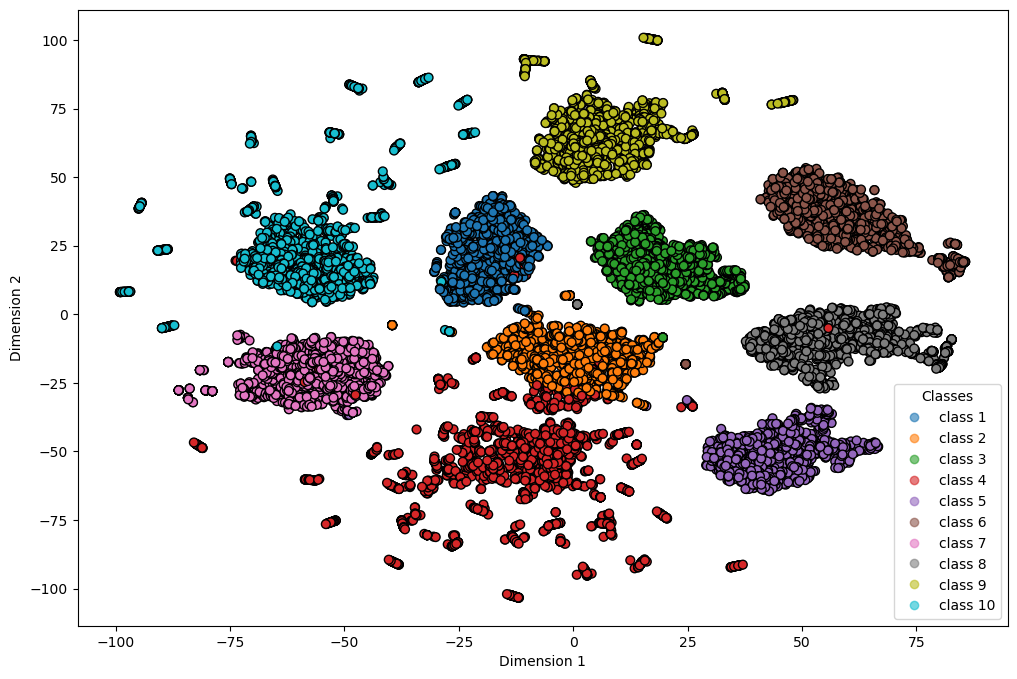

In [30]:
all_list = exp+positive_example_list+negative_example_list
all_msk = msk+positive_attn_list+negative_attn_list
cls_list, preds_list = extract_cls_token(model, all_list, all_msk, device)
visualize_embeddings_TSNE(cls_list, preds_list, 10, random_state=42)

In [32]:
# 7000
print(ret_classification_report(positive_example_list+negative_example_list, positive_example_label+negative_example_label))

Evaluating: 100%|██████████| 7000/7000 [00:04<00:00, 1517.95it/s]

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        72
           1       0.83      0.83      0.83       409
           2       0.00      0.00      0.00        72
           3       0.97      0.98      0.98      2867
           4       0.00      0.00      0.00        67
           5       0.82      0.81      0.82       371
           6       0.81      0.81      0.81       370
           7       0.81      0.81      0.81       373
           8       0.91      0.90      0.91       756
           9       0.96      0.96      0.96      1643

    accuracy                           0.90      7000
   macro avg       0.61      0.61      0.61      7000
weighted avg       0.90      0.90      0.90      7000



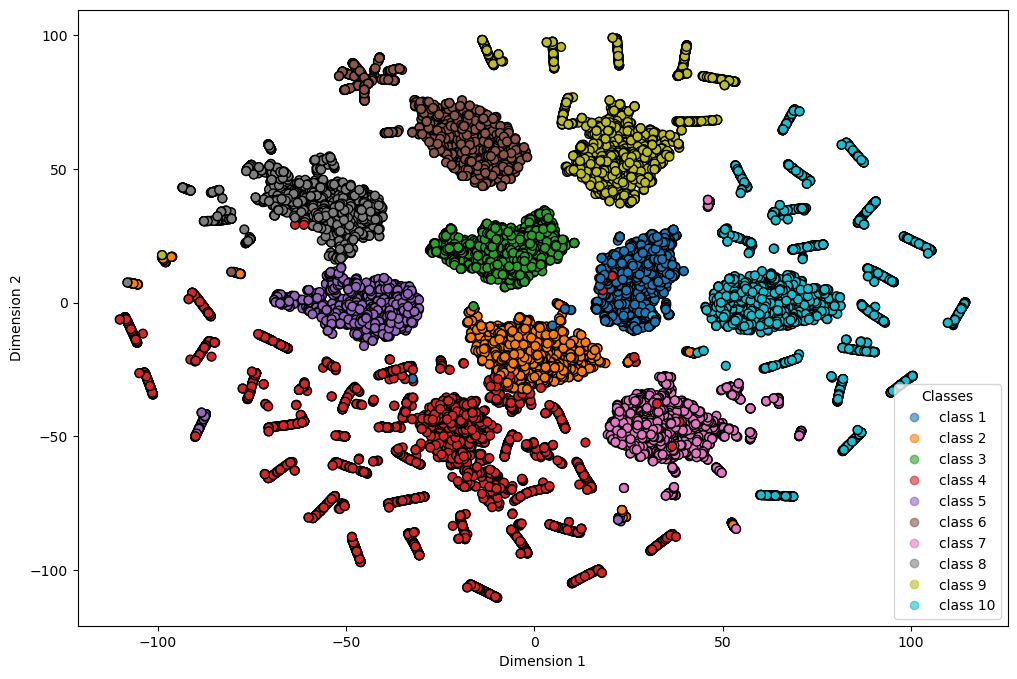

In [33]:
all_list = exp+positive_example_list+negative_example_list
all_msk = msk+positive_attn_list+negative_attn_list
cls_list, preds_list = extract_cls_token(model, all_list, all_msk, device)
visualize_embeddings_TSNE(cls_list, preds_list, 10, random_state=42)

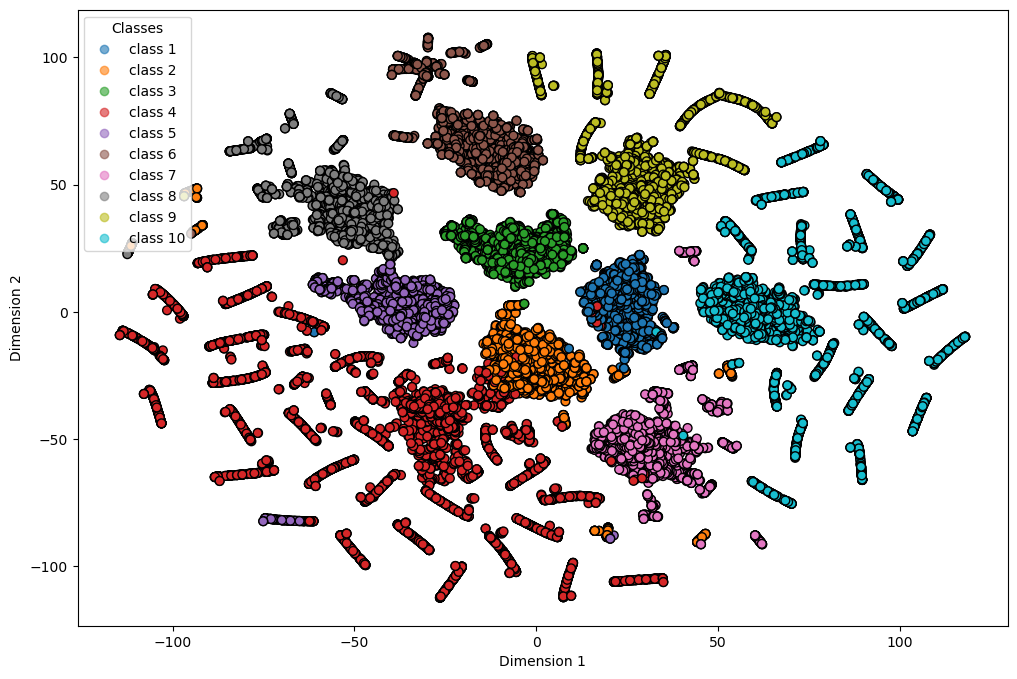

In [37]:
# topp 4 10000
all_list = exp+positive_example_list+negative_example_list
all_msk = msk+positive_attn_list+negative_attn_list
cls_list, preds_list = extract_cls_token(model, all_list, all_msk, device)
visualize_embeddings_TSNE(cls_list, preds_list, 10, random_state=42)

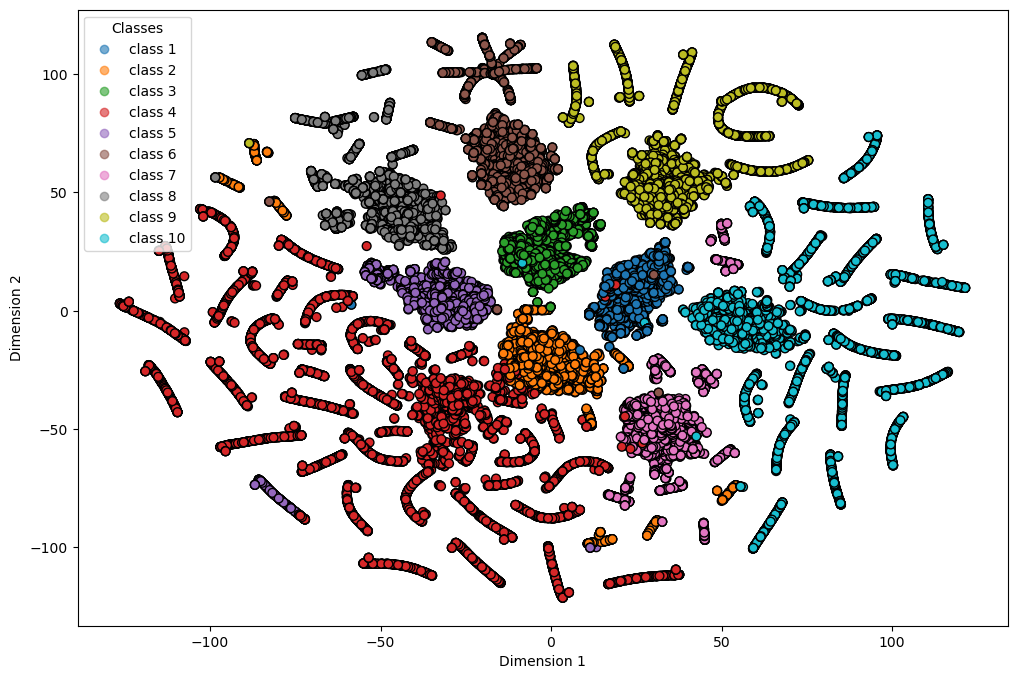

In [48]:
# topp 4 15000
all_list = exp+positive_example_list+negative_example_list
all_msk = msk+positive_attn_list+negative_attn_list
cls_list, preds_list = extract_cls_token(model, all_list, all_msk, device)
visualize_embeddings_TSNE(cls_list, preds_list, 10, random_state=42)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


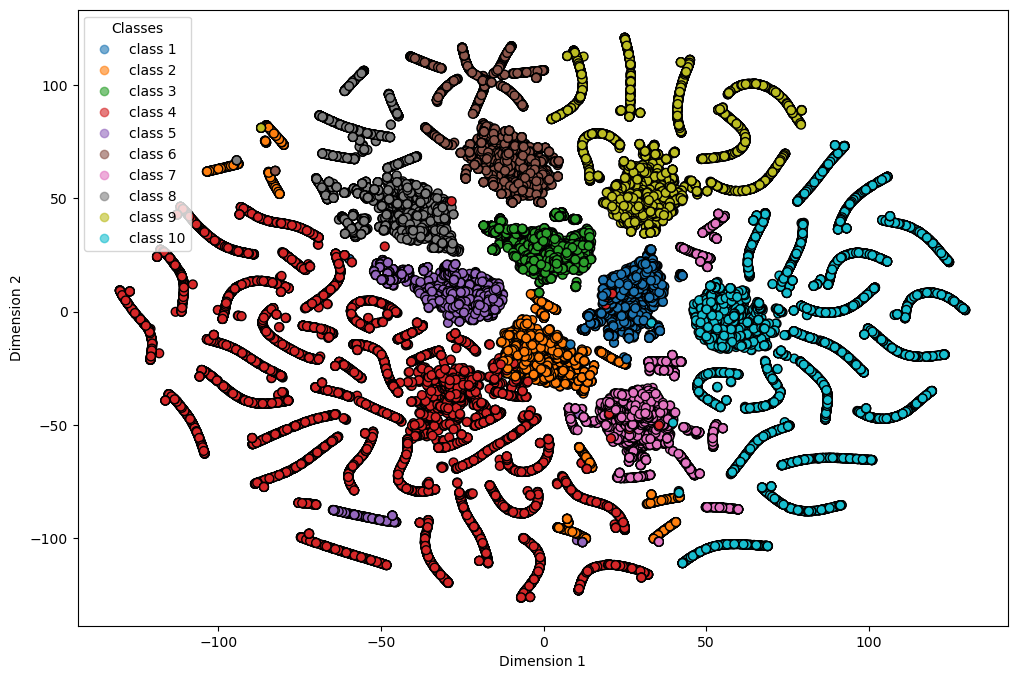

In [27]:
# topp 4 20000
all_list = exp+positive_example_list+negative_example_list
all_msk = msk+positive_attn_list+negative_attn_list
cls_list, preds_list = extract_cls_token(model, all_list, all_msk, device)
visualize_embeddings_TSNE(cls_list, preds_list, 10, random_state=42)

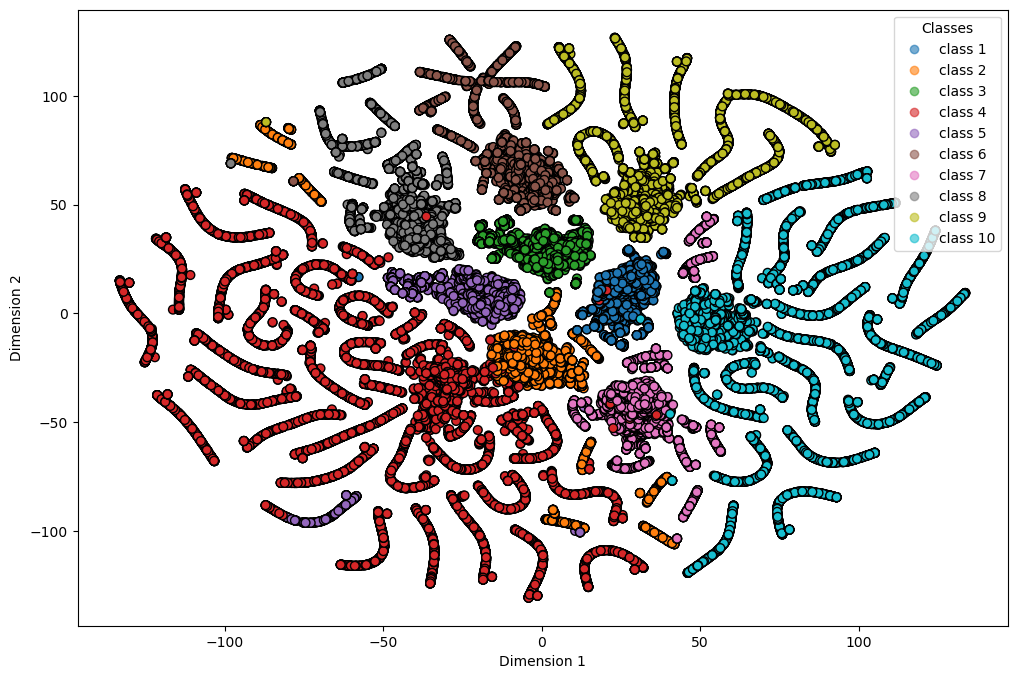

In [29]:
# topp 4 25000
all_list = exp+positive_example_list+negative_example_list
all_msk = msk+positive_attn_list+negative_attn_list
cls_list, preds_list = extract_cls_token(model, all_list, all_msk, device)
visualize_embeddings_TSNE(cls_list, preds_list, 10, random_state=42)

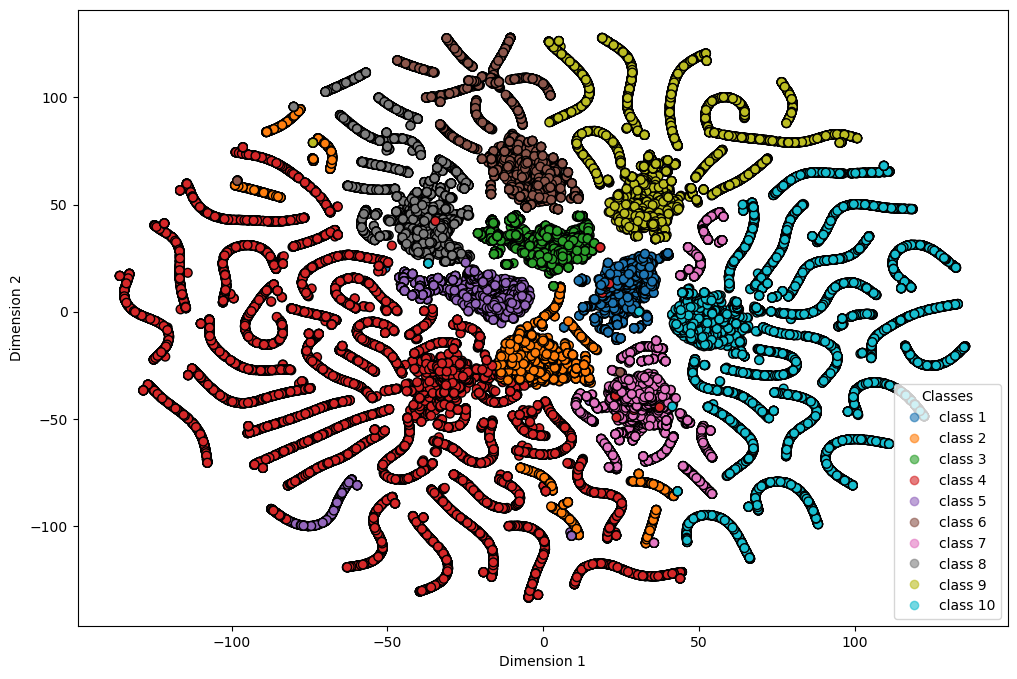

In [31]:
# topp 4 30000
all_list = exp+positive_example_list+negative_example_list
all_msk = msk+positive_attn_list+negative_attn_list
cls_list, preds_list = extract_cls_token(model, all_list, all_msk, device)
visualize_embeddings_TSNE(cls_list, preds_list, 10, random_state=42)

In [191]:
print(ret_classification_report(positive_example_list, positive_example_label))

Evaluating: 100%|██████████| 2700/2700 [00:01<00:00, 1487.90it/s]

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       387
           3       1.00      1.00      1.00      1229
           5       1.00      1.00      1.00       104
           6       1.00      1.00      1.00       104
           7       1.00      1.00      1.00       102
           8       1.00      1.00      1.00       237
           9       1.00      1.00      1.00       537

    accuracy                           1.00      2700
   macro avg       1.00      1.00      1.00      2700
weighted avg       1.00      1.00      1.00      2700



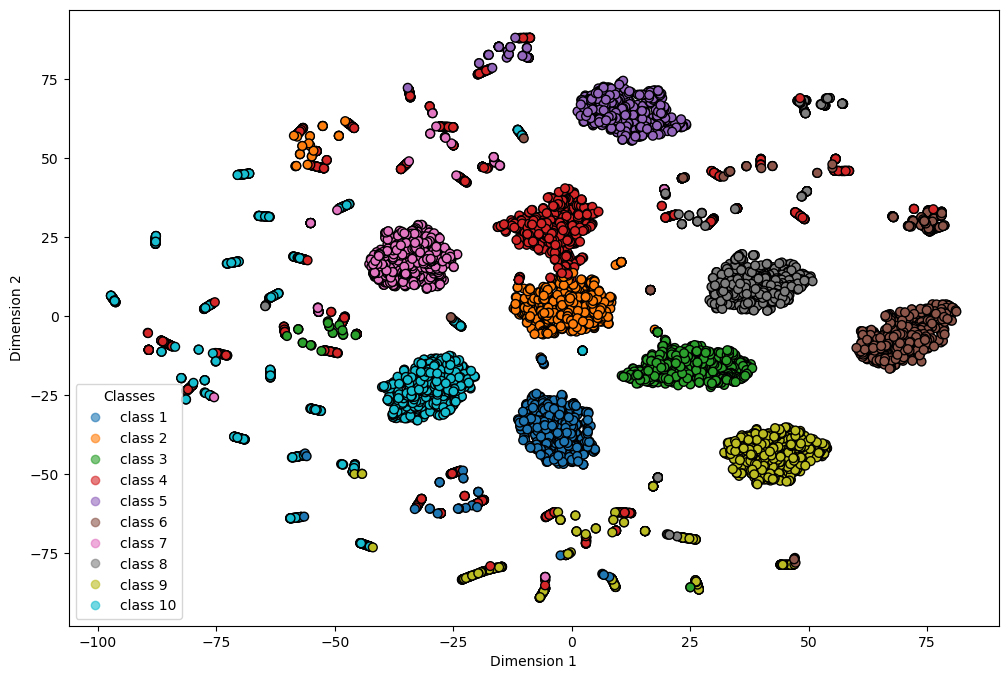

In [207]:
all_list = exp+positive_example_list+negative_example_list
for i in range(3000):
    msk.append(None)
cls_list, preds_list = extract_cls_token(model, all_list, msk, device)
visualize_embeddings_TSNE(cls_list, preds_list, 10, random_state=42)

In [186]:
print(ret_classification_report(negative_example_list, negative_example_label))

Evaluating: 100%|██████████| 300/300 [00:00<00:00, 1428.51it/s]

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      32.0
           1       0.00      0.00      0.00      31.0
           2       0.00      0.00      0.00      31.0
           3       0.00      0.00      0.00      26.0
           4       0.00      0.00      0.00      33.0
           5       0.00      0.00      0.00      31.0
           6       0.00      0.00      0.00      28.0
           7       0.00      0.00      0.00      33.0
           8       0.00      0.00      0.00      30.0
           9       0.00      0.00      0.00      25.0

    accuracy                           0.00     300.0
   macro avg       0.00      0.00      0.00     300.0
weighted avg       0.00      0.00      0.00     300.0



In [26]:
plot_list = []
plot_mask = []
value, mask = extract_bottom_n_embeddings(1000, 10, input_embeds, att_masks)
plot_list.extend(value)
plot_mask.extend(mask)

In [25]:
plot_list = []
plot_mask = []
value, mask = extract_top_n_embeddings(1000, 10, input_embeds, att_masks)
plot_list.extend(value)
plot_mask.extend(mask)

In [26]:
exp = []
msk = []
for i in range(1000):
    for j in range(10):
        exp.append(plot_list[i][j])
        msk.append(plot_mask[i][j])

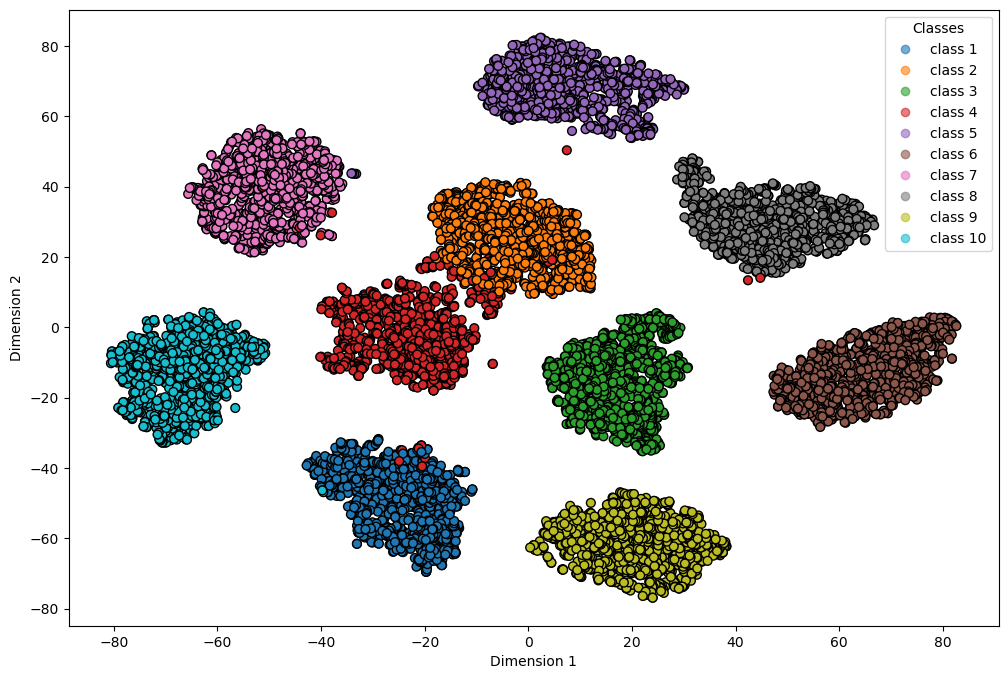

In [312]:
cls_list, preds_list = extract_cls_token(model, exp, msk, device)
visualize_embeddings_TSNE(cls_list, preds_list, 10, random_state=42)

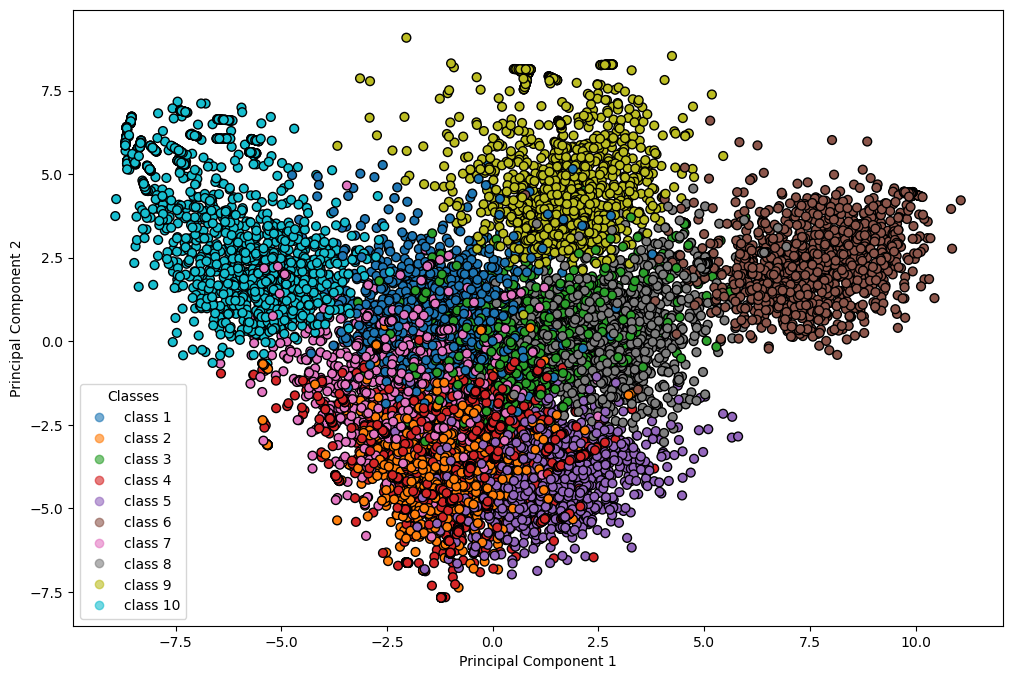

In [314]:
visualize_embeddings_PCA(cls_list, preds_list, 10, random_state=42)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


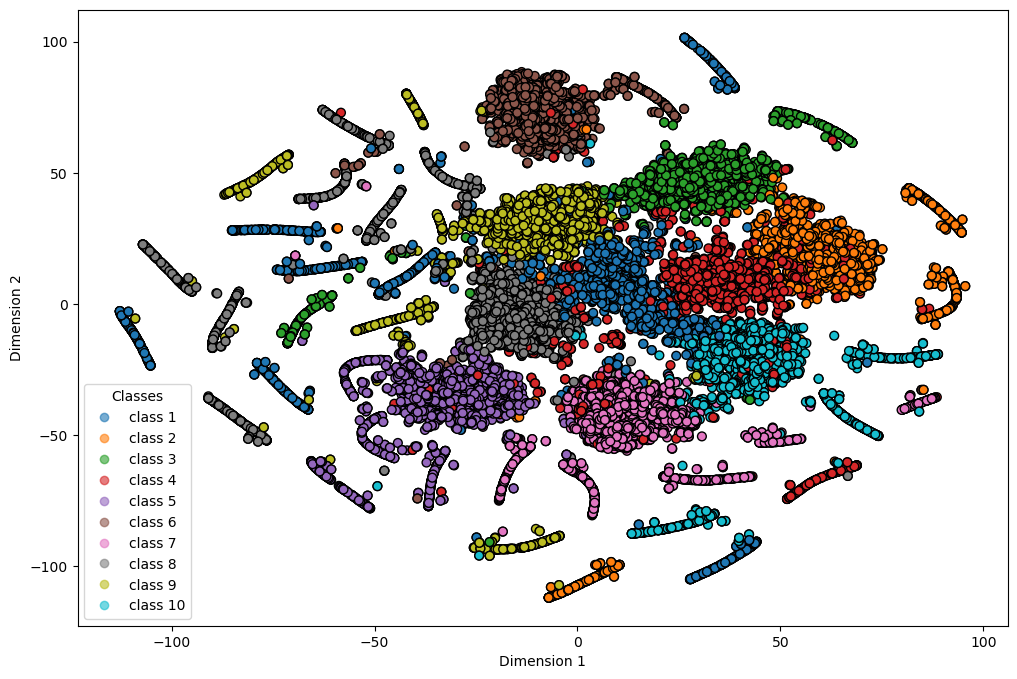

In [29]:
# bottom 4 7000
all_list = exp+positive_example_list+negative_example_list
all_msk = msk+positive_attn_list+negative_attn_list
cls_list, preds_list = extract_cls_token(model, all_list, all_msk, device)
visualize_embeddings_TSNE(cls_list, preds_list, 10, random_state=42)

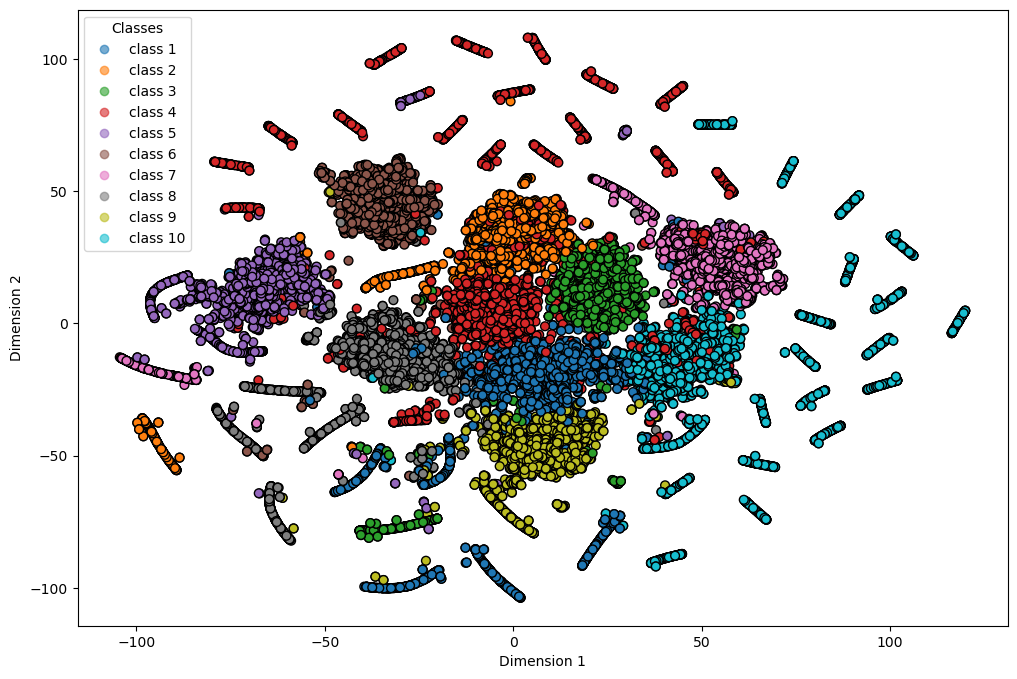

In [31]:
# top2 bottom 2 7000
all_list = exp+positive_example_list+negative_example_list
all_msk = msk+positive_attn_list+negative_attn_list
cls_list, preds_list = extract_cls_token(model, all_list, all_msk, device)
visualize_embeddings_TSNE(cls_list, preds_list, 10, random_state=42)